# Case Studies: SARS-CoV-2 in a Community (Part 3)

## Introduction

In Parts 1 and 2 we used a basic **SIR model** (Susceptible → Infected → Recovered) on various network types, treating all agents uniformly. Here we move to a more realistic scenario:

> **A community of 1,000 individuals split into two behavioral groups: high-contact front-line workers and a lower-contact general public.**

Three features make this setting more complex:

1. **Hospitalization dynamics (SIHR model)** — infected individuals may develop severe disease and be admitted to hospital before recovering. Hospitalized agents are isolated and do not transmit further.
2. **Contact-rate heterogeneity** — front-line/essential workers (retail, transit, delivery, care work) have *high contact rates*, while the rest of the public keeps *lower contact rates* (reduced mobility, working from home). This asymmetry shapes who drives the outbreak.
3. **Adaptive intervention: PPE adoption** — as hospitalizations become visible, high-contact workers adopt personal protective equipment (PPE/masks), reducing their transmission. This is a *negative feedback loop* that dampens the outbreak.

### Model compartments

| Symbol | Meaning |
|--------|---------|
| **S** | Susceptible — not yet infected |
| **I** | Infected — infectious, circulating in the community |
| **H** | Hospitalized — severe case, isolated and removed from transmission |
| **R** | Recovered — immune |

### Agent properties

- `contact_rate = :high` — front-line worker: transmits at `trans_prob` per susceptible neighbor per step
- `contact_rate = :low` — general public: transmits at `trans_prob × low_risk_factor`

## Setup

In [21]:
cd(@__DIR__)

# Per-notebook output directories
const FIGURES_DIR = "figures/part3"
const DATA_DIR    = "data/part3"

mkpath(FIGURES_DIR)
mkpath(DATA_DIR)
mkpath("output")

using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using Agents, Graphs, Random, Plots, DataFrames, CSV,
      Statistics, StatsBase, StatsPlots, Measures, CategoricalArrays

include("src/create_graph.jl")

@agent struct Person(GraphAgent)
    status::Symbol       = :S
    days_infected::Int   = 0
    contact_rate::Symbol = :high
end

include("src/initialize.jl")
include("src/agent_step.jl")

function model_step!(model::AgentBasedModel)
    model.susceptible_count  = sum(model[i].status == :S for i in 1:nv(model.graph))
    model.infected_count     = sum(model[i].status == :I for i in 1:nv(model.graph))
    model.hospitalized_count = sum(model[i].status == :H for i in 1:nv(model.graph))
    model.recovered_count    = sum(model[i].status == :R for i in 1:nv(model.graph))
end

  Activating project at `c:\Users\Leonard\julia-workspace\espidam-tutorial-2026`


model_step! (generic function with 1 method)

---
## Section A: Baseline Community Outbreak (SIHR Model)

We begin with a simple baseline: all agents have a **high contact rate** (homogeneous population) on a **preferential-attachment network** (a few highly-connected hubs bridge many smaller clusters).

The SIHR model adds a hospitalization stage: with probability `hospitalization_prob`, a newly infected agent develops severe disease and is admitted to hospital on day 1 rather than continuing to circulate. Hospitalized agents are isolated (do not transmit) and recover after `days_to_hospital_recovery` days.

We compare:
- **SIR** (`use_hospitalization=false`): everyone circulates until recovery
- **SIHR** (`use_hospitalization=true`): a fraction of infections are removed to hospital immediately

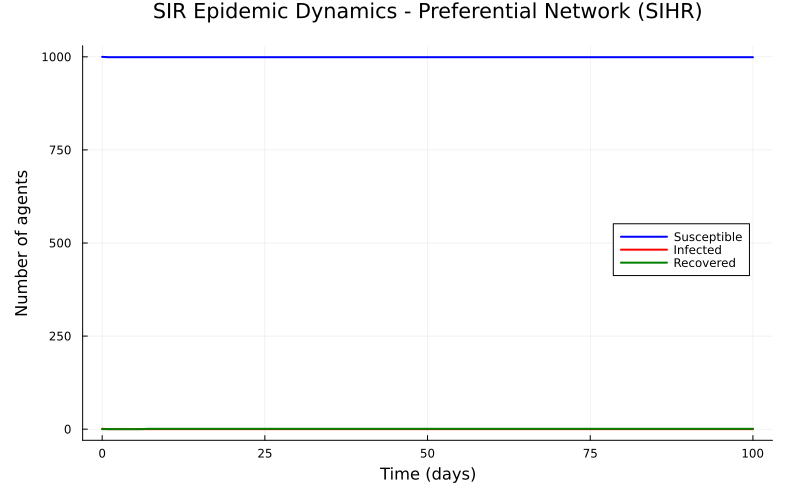

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\baseline_sihr.pdf"

In [22]:
include("src/plotting.jl")

model_sihr = initialize(;
    network_type=:preferential,
    mean_degree=4,
    patient_zero=:maxdegree,
    use_hospitalization=true,
    hospitalization_prob=0.15,
    days_to_hospital_recovery=7,
)

adata = [:status]
mdata = [:susceptible_count, :infected_count, :hospitalized_count, :recovered_count]
_, mdf_sihr = run!(model_sihr, 100; adata, mdata)

p_sihr = plot_epidemic_trajectories(mdf_sihr, :preferential; title_suffix=" (SIHR)")
display(p_sihr)
savefig(p_sihr, joinpath(FIGURES_DIR, "baseline_sihr.pdf"))

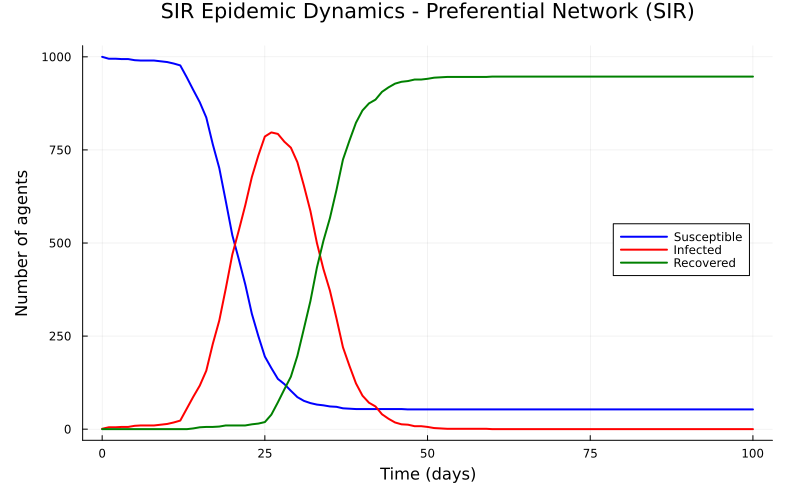

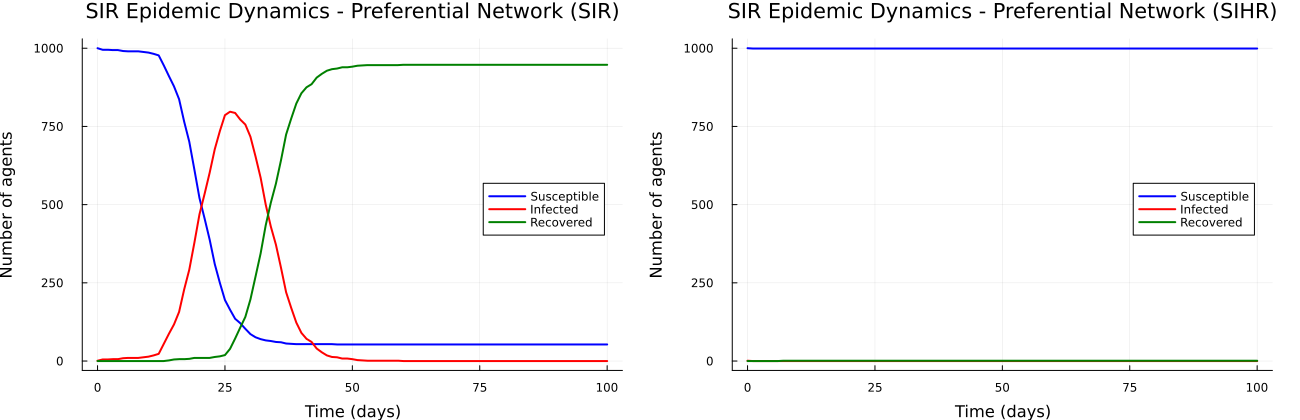

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\sir_vs_sihr.pdf"

In [23]:
model_sir = initialize(;
    network_type=:preferential,
    mean_degree=4,
    patient_zero=:maxdegree,
    use_hospitalization=false,
)

mdata_sir = [:susceptible_count, :infected_count, :recovered_count]
_, mdf_sir = run!(model_sir, 100; adata, mdata=mdata_sir)

p_sir = plot_epidemic_trajectories(mdf_sir, :preferential; title_suffix=" (SIR)")
display(p_sir)

p_compare = plot(p_sir, p_sihr, layout=(1,2), size=(1300, 420), margin=5Measures.mm)
display(p_compare)
savefig(p_compare, joinpath(FIGURES_DIR, "sir_vs_sihr.pdf"))

**Observation:** In SIHR, a fraction of infected agents are immediately removed to hospital and stop transmitting. This typically lowers the peak infection count and may shorten the epidemic relative to SIR, though the total recovered count (including hospitalized) remains similar.

---
## Section B: Contact Heterogeneity — Where Are the High-Contact Workers?

Now we introduce **contact-rate heterogeneity**: 10% of agents are high-contact front-line workers (`contact_rate = :high`) and 90% are lower-contact members of the general public (`contact_rate = :low`). The general public transmits at `low_risk_factor = 0.3` times the front-line rate — reflecting reduced mobility and fewer daily contacts.

The key question: **does the placement of high-contact workers on the network change the outbreak?**

We compare three placement strategies:
- `:random` — high-contact workers placed at random nodes
- `:maxdegree` — placed at the most-connected nodes (hubs)
- `:maxbetweenness` — placed at nodes on the most shortest paths (bridges)

The hypothesis: placing high-contact individuals at central nodes creates super-spreaders and accelerates the epidemic.

In [24]:
include("src/run_simulations.jl")
include("src/plotting.jl")

# Common parameters for all placement strategies
hcw_params = (
    network_type    = :preferential,
    mean_degree     = 4,
    fraction_high_contact = 0.1,
    low_risk_factor = 0.3,
    patient_zero    = :maxdegree,
    use_hospitalization = true,
)

results_placement = Dict()
for strategy in [:random, :maxdegree, :maxbetweenness]
    println("Running simulations for high_contact=$(strategy)...")
    results_placement[strategy] = run_simulations(;
        hcw_params...,
        high_contact=strategy,
    )
end
println("Done.")

Running simulations for high_contact=random...
Running simulations for high_contact=maxdegree...
Running simulations for high_contact=maxbetweenness...
Done.


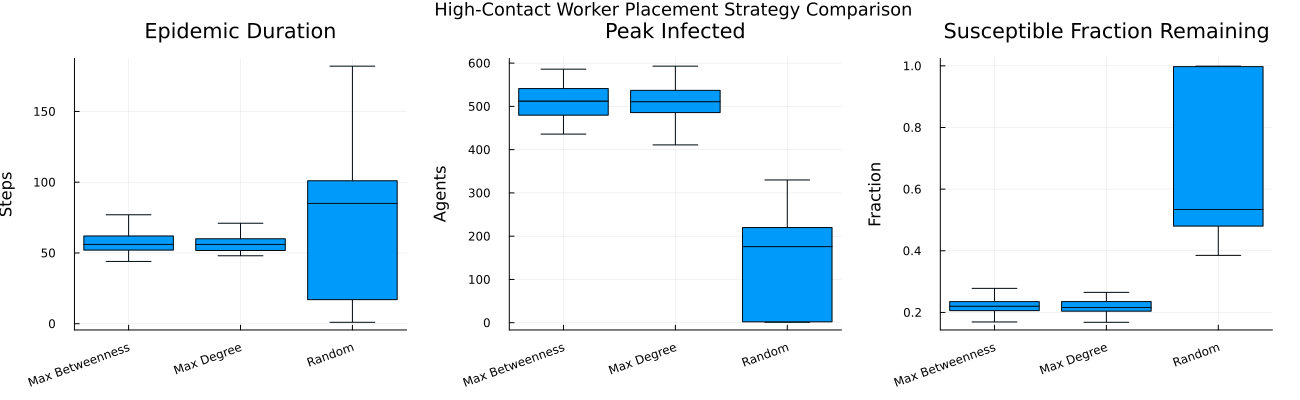

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\hcw_placement.pdf"

In [25]:
placement_labels = ["Random", "Max Degree", "Max Betweenness"]
strategies = [:random, :maxdegree, :maxbetweenness]

duration_data = DataFrame(value=Float64[], placement=String[])
maxinf_data   = DataFrame(value=Float64[], placement=String[])
sfr_data      = DataFrame(value=Float64[], placement=String[])

for (strategy, label) in zip(strategies, placement_labels)
    mdf = results_placement[strategy]
    grouped = groupby(mdf, :seed)
    for gdf in grouped
        first_inf = findfirst(gdf.infected_count .> 0)
        last_inf  = findlast(gdf.infected_count .> 0)
        dur = isnothing(last_inf) ? nrow(gdf) : last_inf - first_inf + 1
        push!(duration_data, (dur, label))
        push!(maxinf_data,   (maximum(gdf.infected_count), label))
        last_row = last(gdf)
        total = last_row.susceptible_count + last_row.infected_count +
                last_row.hospitalized_count + last_row.recovered_count
        push!(sfr_data, (last_row.susceptible_count / total, label))
    end
end

bp1 = boxplot(duration_data.placement, duration_data.value;
    title="Epidemic Duration", ylabel="Steps", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)
bp2 = boxplot(maxinf_data.placement, maxinf_data.value;
    title="Peak Infected", ylabel="Agents", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)
bp3 = boxplot(sfr_data.placement, sfr_data.value;
    title="Susceptible Fraction Remaining", ylabel="Fraction", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)

p_placement = plot(bp1, bp2, bp3, layout=(1,3), size=(1300, 400),
    plot_title="High-Contact Worker Placement Strategy Comparison", plot_titlefontsize=12,
    bottom_margin=10Measures.mm)
display(p_placement)
savefig(p_placement, joinpath(FIGURES_DIR, "hcw_placement.pdf"))

---
## Section C: Sensitivity to High-Contact Fraction and Public Transmission Rate

How sensitive are the outbreak dynamics to:
1. **High-contact fraction** (`fraction_high_contact`): what share of the population are front-line workers?
2. **Public transmission rate** (`low_risk_factor`): how much does the lower-contact general public contribute to spread relative to front-line workers?

We sweep both parameters and look at the peak number of hospitalized agents — a proxy for healthcare-system burden.

In [26]:
# Parameter sweep: fraction_high_contact × low_risk_factor
hcw_fractions  = [0.05, 0.10, 0.15, 0.20, 0.25]
low_risk_factors = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

peak_hosp_matrix = zeros(length(hcw_fractions), length(low_risk_factors))

for (i, fhc) in enumerate(hcw_fractions)
    for (j, lrf) in enumerate(low_risk_factors)
        println("fraction_high_contact=$(fhc), low_risk_factor=$(lrf)")
        mdf = run_simulations(;
            network_type=:preferential,
            mean_degree=4,
            high_contact=:maxdegree,
            fraction_high_contact=Float64(fhc),
            low_risk_factor=Float64(lrf),
            patient_zero=:maxdegree,
            use_hospitalization=true,
        )
        # Mean peak hospitalized across seeds
        peak_hosp_matrix[i, j] = mean(
            combine(groupby(mdf, :seed), :hospitalized_count => maximum => :peak).peak
        )
    end
end
println("Sweep complete.")

fraction_high_contact=0.05, low_risk_factor=0.1
fraction_high_contact=0.05, low_risk_factor=0.2
fraction_high_contact=0.05, low_risk_factor=0.4
fraction_high_contact=0.05, low_risk_factor=0.6
fraction_high_contact=0.05, low_risk_factor=0.8
fraction_high_contact=0.05, low_risk_factor=1.0
fraction_high_contact=0.1, low_risk_factor=0.1
fraction_high_contact=0.1, low_risk_factor=0.2
fraction_high_contact=0.1, low_risk_factor=0.4
fraction_high_contact=0.1, low_risk_factor=0.6
fraction_high_contact=0.1, low_risk_factor=0.8
fraction_high_contact=0.1, low_risk_factor=1.0
fraction_high_contact=0.15, low_risk_factor=0.1
fraction_high_contact=0.15, low_risk_factor=0.2
fraction_high_contact=0.15, low_risk_factor=0.4
fraction_high_contact=0.15, low_risk_factor=0.6
fraction_high_contact=0.15, low_risk_factor=0.8
fraction_high_contact=0.15, low_risk_factor=1.0
fraction_high_contact=0.2, low_risk_factor=0.1
fraction_high_contact=0.2, low_risk_factor=0.2
fraction_high_contact=0.2, low_risk_factor=0.4
f

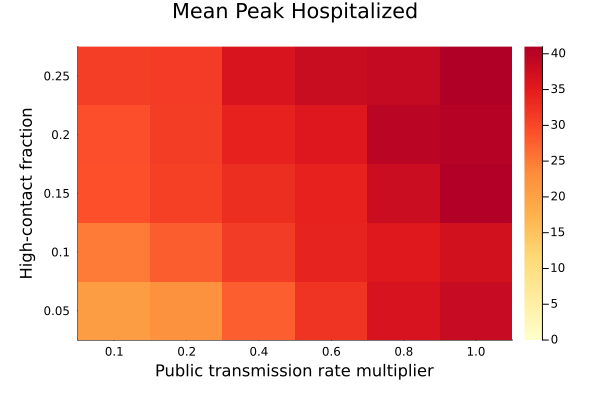

In [27]:
p_heatmap = heatmap(
    string.(low_risk_factors), string.(hcw_fractions), peak_hosp_matrix;
    xlabel="Public transmission rate multiplier",
    ylabel="High-contact fraction",
    title="Mean Peak Hospitalized",
    color=:YlOrRd,
    size=(600, 400),
    margin=5Measures.mm,
    clims=(0, maximum(peak_hosp_matrix)),
)
savefig(p_heatmap, joinpath(FIGURES_DIR, "peak_hospitalized_heatmap.pdf"));
display(p_heatmap)

---
## Section D: PPE Adoption as an Adaptive Intervention

In reality, people respond to the outbreak: as hospitalizations become visible, high-contact front-line workers adopt PPE (masks and other protective equipment), reducing their transmission. Rather than flipping individual agents between contact states, we model this as a **graded behavioral response** that scales down high-contact transmission as a function of the observed hospitalization burden.

Each step, the effective transmission probability of a high-contact agent is multiplied by an *awareness* factor:

$$\text{awareness} = 1 - \text{max\_ppe\_reduction} \cdot \frac{s}{s + \text{ppe\_half\_saturation}}, \qquad s = \frac{\text{hospitalized\_count}}{\text{n\_nodes}}$$

This is a **saturating** response, bounded in $(1 - \texttt{max\_ppe\_reduction},\ 1]$ by construction — no arbitrary multiplier and no need to clamp a probability:

- `max_ppe_reduction` — the strongest cut PPE can achieve (e.g. `0.8` → up to 80% less high-contact transmission).
- `ppe_half_saturation` — the hospitalized fraction at which the response reaches *half* its maximum (smaller → workers react earlier).

Because awareness depends on the *current* signal, it rises as hospitalizations climb and relaxes back as they fall — a negative feedback loop without any explicit state-switching:
- ↑ hospitalizations → ↑ PPE response → ↓ high-contact transmission → ↓ hospitalizations

Note the response applies only to high-contact (`:high`) transmission; the general public keeps its fixed `low_risk_factor`.

We compare three scenarios by varying `max_ppe_reduction`:
- `0.0` — no PPE adoption (baseline)
- `0.5` — moderate PPE (up to 50% cut in high-contact transmission)
- `0.8` — strong PPE (up to 80% cut)

**Hypothesis:** A stronger PPE response (higher `max_ppe_reduction`) flattens the hospitalization curve and reduces peak burden.

In [28]:
# Run simulations for different PPE response strengths
ppe_reductions = [0.0, 0.5, 0.8]
ppe_labels = ["No PPE (0% cut)", "Moderate PPE (50% cut)", "Strong PPE (80% cut)"]

results_ppe = Dict()
for red in ppe_reductions
    println("Running max_ppe_reduction=$(red)...")
    results_ppe[red] = run_simulations(;
        network_type=:preferential,
        mean_degree=4,
        high_contact=:maxdegree,
        fraction_high_contact=0.1,
        low_risk_factor=0.1,
        patient_zero=:maxdegree,
        use_hospitalization=true,
        use_ppe_adoption=(red > 0.0),
        max_ppe_reduction=Float64(red),
    )
end
println("Done.")

Running max_ppe_reduction=0.0...
Running max_ppe_reduction=0.5...
Running max_ppe_reduction=0.8...
Done.


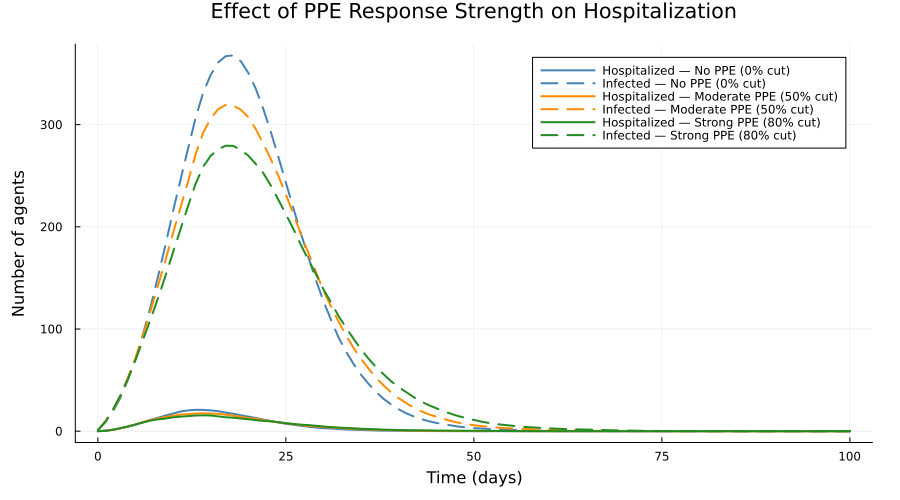

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\ppe_adoption.pdf"

In [29]:
colors = [:steelblue, :darkorange, :forestgreen]
p_ppe = plot(size=(900, 500), xlabel="Time (days)", ylabel="Number of agents",
    title="Effect of PPE Response Strength on Hospitalization",
    legend=:topright, margin=5Measures.mm)

for (red, label, col) in zip(ppe_reductions, ppe_labels, colors)
    mdf = results_ppe[red]
    mean_traj = combine(groupby(mdf, :time),
        :hospitalized_count => mean => :mean_hosp,
        :infected_count     => mean => :mean_inf,
    )
    sort!(mean_traj, :time)
    plot!(p_ppe, mean_traj.time, mean_traj.mean_hosp;
        label="Hospitalized — $(label)", linewidth=2, color=col)
    plot!(p_ppe, mean_traj.time, mean_traj.mean_inf;
        label="Infected — $(label)", linewidth=2, color=col, linestyle=:dash)
end

display(p_ppe)
savefig(p_ppe, joinpath(FIGURES_DIR, "ppe_adoption.pdf"))

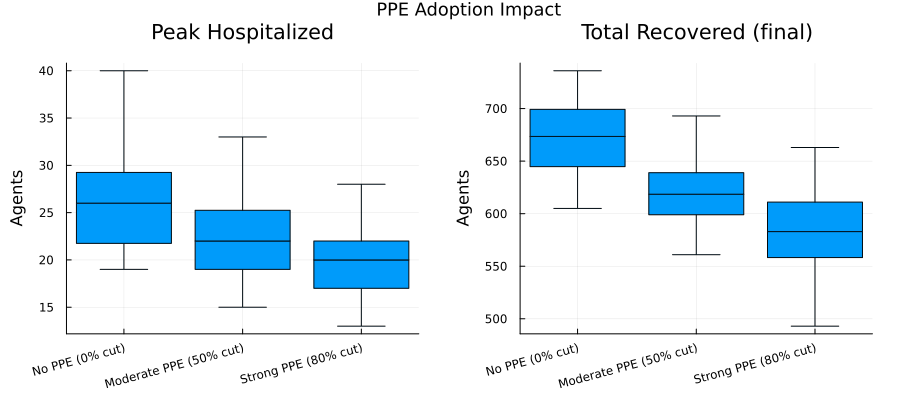

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\ppe_boxes.pdf"

In [30]:
peak_hosp_ppe = DataFrame(value=Float64[], scenario=String[])
total_rec_ppe = DataFrame(value=Float64[], scenario=String[])

for (red, label) in zip(ppe_reductions, ppe_labels)
    mdf = results_ppe[red]
    for gdf in groupby(mdf, :seed)
        push!(peak_hosp_ppe, (maximum(gdf.hospitalized_count), label))
        push!(total_rec_ppe,  (last(gdf).recovered_count, label))
    end
end

# Convert to ordered categorical so boxplots respect the scenario order
for df in (peak_hosp_ppe, total_rec_ppe)
    df.scenario = CategoricalArray(df.scenario; ordered=true, levels=ppe_labels)
end

bp_hosp = boxplot(peak_hosp_ppe.scenario, peak_hosp_ppe.value;
    title="Peak Hospitalized", ylabel="Agents", legend=false,
    outliers=false, xrotation=15, margin=5Measures.mm)
bp_rec = boxplot(total_rec_ppe.scenario, total_rec_ppe.value;
    title="Total Recovered (final)", ylabel="Agents", legend=false,
    outliers=false, xrotation=15, margin=5Measures.mm)

p_ppe_boxes = plot(bp_hosp, bp_rec, layout=(1,2), size=(900, 420),
    plot_title="PPE Adoption Impact", plot_titlefontsize=12,
    bottom_margin=12Measures.mm)
display(p_ppe_boxes)
savefig(p_ppe_boxes, joinpath(FIGURES_DIR, "ppe_boxes.pdf"))

**Expected result:** A stronger PPE response (higher `max_ppe_reduction`) should reduce both peak hospitalizations and total recovered (smaller final epidemic size), because high-contact transmission is throttled as the outbreak becomes visible. If the curves overlap, the response may be saturating too late — try lowering `ppe_half_saturation` (so workers react earlier), raising `max_ppe_reduction`, or increasing `fraction_high_contact` so high-contact workers drive more of the transmission.